In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import os
from dotenv import load_dotenv
import pickle
import warnings

warnings.filterwarnings('ignore')

In [6]:
load_dotenv()

True

**TO ACCESS DATASET ON COLLAB**

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset/

Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset/versions/
License(s): copyright-authors
100% 2.70G/2.70G [02:33<00:00, 18.8MB/s]



In [ ]:
import zipfile
with zipfile.ZipFile('new-plant-diseases-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [ ]:
TRAIN_DIR = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
VALID_DIR = '/content/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'
TEST_DIR = '/content/test/test'

In [7]:
TRAIN_DIR = os.getenv("train_folder")
TEST_DIR = os.getenv("test_folder")
VALID_DIR = os.getenv("valid_folder")

In [8]:
import torch
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

In [9]:
IMAGE_SIZE = (224,224)
BATCH_SIZE = 32

**TRAIN VALIDATION TRANSFROMS**

In [10]:
train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.15),
    transforms.ToTensor()
])

In [11]:
valid_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

In [12]:
train_dataset = ImageFolder(root = TRAIN_DIR, transform = train_transforms)
valid_dataset = ImageFolder(root = VALID_DIR, transform= valid_transforms)

In [13]:
class_names = train_dataset.classes
print(len(class_names))
class_names

38


['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

**DATALOADER FOR TRAIN AND TEST DATASET**

In [14]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)

valid_dataloader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

In [15]:
images, labels = next(iter(train_dataloader))

In [16]:
images[0].shape

torch.Size([3, 224, 224])

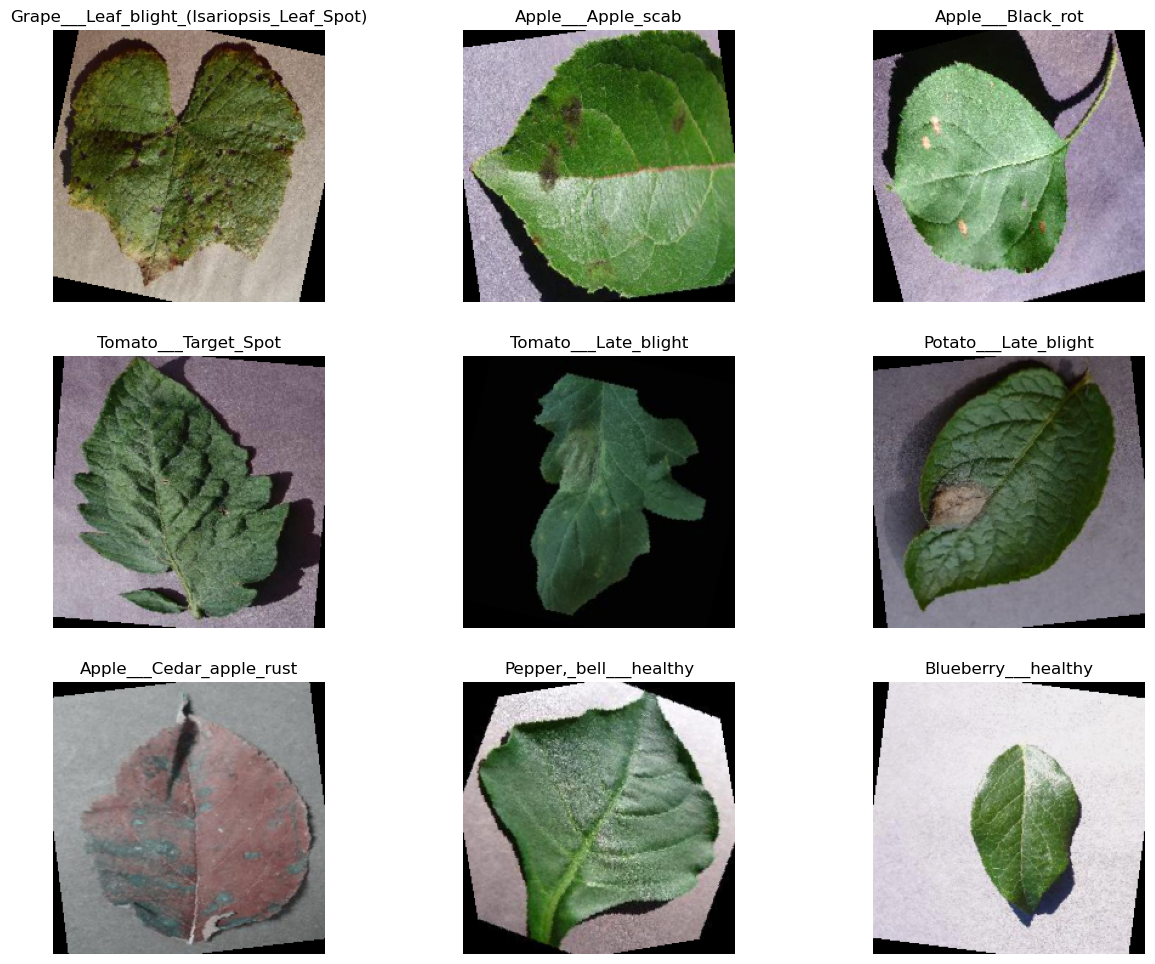

In [17]:
plt.figure(figsize=(15, 12))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    img = images[i].permute(1, 2, 0)
    plt.imshow(img)
    plt.title(class_names[labels[i]], fontsize=12)
    plt.axis("off")


plt.show()

In [18]:
len(train_dataloader)*32

70304

**CNN CLASS ARCH**

In [19]:
3*224*224

16*224*224
16*112*112

32*112*112
32*56*56

64*56*56
64*28*28

50176

In [20]:
class CustomNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.feature_extract = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3 , padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(16),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride=2),


            nn.Conv2d(32, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Dropout(0.2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(64*28*28, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64,num_classes)
        )

    def forward(self,X):
        out = self.feature_extract(X)
        out = self.classifier(out)

        return out

In [21]:
learning_rate = 0.05
epochs = 30

In [22]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [23]:
model = CustomNN(num_classes=len(class_names)).to(device)

In [24]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [25]:
images, labels = next(iter(train_dataloader))

images = images.to(device)

outputs = model(images)

print(outputs.shape)

torch.Size([32, 38])


**MODEL TRAINING AND VALIDATION FUNCs**

In [26]:
def train_block(model, train_dataloader, criterion, optimizer, device):
  model.train()

  total_batch_loss = 0.0
  correctly_predicted = 0
  total = 0

  for images, labels in train_dataloader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()
    output = model(images)
    loss = criterion(output, labels)
    loss.backward()
    optimizer.step()

    total_batch_loss += loss.item()
    total += len(labels)
    _,predicted = torch.max(output, 1)
    correctly_predicted += (predicted == labels).sum().item()

  epoch_loss = total_batch_loss/len(train_dataloader)
  acc = correctly_predicted/total

  return epoch_loss, acc

In [27]:
def val_block(model, valid_dataloader, criterion, device):

  model.eval()

  total_batch_loss = 0.0
  correctly_predicted = 0
  total = 0

  with torch.no_grad():

    for images, labels in valid_dataloader:
      images = images.to(device)
      labels = labels.to(device)


      output = model(images)
      loss = criterion(output, labels)

      total_batch_loss += loss.item()
      total += len(labels)
      _,predicted = torch.max(output, 1)
      correctly_predicted += (predicted == labels).sum().item()

    epoch_loss = total_batch_loss/len(valid_dataloader)
    acc = correctly_predicted/total

  return epoch_loss, acc

In [ ]:
train_losses = []
valid_losses = []

train_accs = []
valid_accs = []

**TRANING AND VALIDATING PER EPOCH**

In [ ]:
for epoch in range(epochs):

  train_loss, train_acc = train_block(model, train_dataloader, criterion, optimizer, device)
  valid_loss, valid_acc = val_block(model, valid_dataloader, criterion, device)

  train_losses.append(train_loss)
  train_accs.append(train_acc)

  valid_losses.append(valid_loss)
  valid_accs.append(valid_acc)

  print(f'epoch {epoch+1} train_loss {train_loss} train_acc {train_acc} valid_loss {valid_loss} valid_acc {valid_acc}')

epoch 1 train_loss 2.5512451036550483 train_acc 0.24461199231808806 valid_loss 1.600484081921591 valid_acc 0.4973821989528796
epoch 2 train_loss 1.9813860828463035 train_acc 0.3965289138630059 valid_loss 0.9881121358206623 valid_acc 0.7003755975415433
epoch 3 train_loss 1.6253860617801716 train_acc 0.5054129027669109 valid_loss 1.504863414515487 valid_acc 0.5716480764853176
epoch 4 train_loss 1.4541504705391746 train_acc 0.5597979941674373 valid_loss 0.7784212768662043 valid_acc 0.7680969724561802
epoch 5 train_loss 1.3265765743956655 train_acc 0.6013798989970838 valid_loss 0.6074072120839661 valid_acc 0.8319485545185522
epoch 6 train_loss 1.2128910030296405 train_acc 0.6345401522156625 valid_loss 0.4790779516110276 valid_acc 0.8466310038697928
epoch 7 train_loss 1.155950922639358 train_acc 0.6563482466747279 valid_loss 0.6378607076428947 valid_acc 0.8120305030730708
epoch 8 train_loss 1.0915775248474786 train_acc 0.6747990610996515 valid_loss 0.3911738911515303 valid_acc 0.88168677441

In [ ]:
for epoch in range(20,30):

  train_loss, train_acc = train_block(model, train_dataloader, criterion, optimizer, device)
  valid_loss, valid_acc = val_block(model, valid_dataloader, criterion, device)

  train_losses.append(train_loss)
  train_accs.append(train_acc)

  valid_losses.append(valid_loss)
  valid_accs.append(valid_acc)

  print(f'epoch {epoch+1} train_loss {train_loss} train_acc {train_acc} valid_loss {valid_loss} valid_acc {valid_acc}')

epoch 21 train_loss 0.7849701041110712 train_acc 0.7706095739384025 valid_loss 0.19378004187895503 valid_acc 0.9453107216025495
epoch 22 train_loss 0.7919167030600998 train_acc 0.7715200227612206 valid_loss 0.20167145404029022 valid_acc 0.940701115410881
epoch 23 train_loss 0.7686854940235045 train_acc 0.7777366811295255 valid_loss 0.1800924466620894 valid_acc 0.950091053949465
epoch 24 train_loss 0.7664175944357879 train_acc 0.777907390283804 valid_loss 0.15006076317143693 valid_acc 0.9578875483724106
epoch 25 train_loss 0.7547890903817344 train_acc 0.7809801550608151 valid_loss 0.15308754509095382 valid_acc 0.9545299339858866
epoch 26 train_loss 0.7458173705262382 train_acc 0.7850060459492141 valid_loss 0.15227586060346876 valid_acc 0.9592533576143866
epoch 27 train_loss 0.7288671324184715 train_acc 0.7896009673518742 valid_loss 0.12775822211964252 valid_acc 0.9619849760983382
epoch 28 train_loss 0.7299655184156525 train_acc 0.7878369727576642 valid_loss 0.18777389153251414 valid_acc

In [ ]:
train_losses

[2.5512451036550483,
 1.9813860828463035,
 1.6253860617801716,
 1.4541504705391746,
 1.3265765743956655,
 1.2128910030296405,
 1.155950922639358,
 1.0915775248474786,
 1.0298539296735347,
 1.0084375094488418,
 0.9613750535464037,
 0.9450341777729347,
 0.9105212299469443,
 0.8950286857719361,
 0.8807871772869099,
 0.861146052994943,
 0.8437667521404363,
 0.8213391767871558,
 0.8232694860407044,
 0.8040684281314673]

**GOOGLE COLLAB TO PC, I NEED THIS DATA**

In [28]:
train_losses = [
    2.5512451036550483,
    1.9813860828463035,
    1.6253860617801716,
    1.4541504705391746,
    1.3265765743956655,
    1.2128910030296405,
    1.155950922639358,
    1.0915775248474786,
    1.0298539296735347,
    1.0084375094488418,
    0.9613750535464037,
    0.9450341777729347,
    0.9105212299469443,
    0.8950286857719361,
    0.8807871772869099,
    0.861146052994943,
    0.8437667521404363,
    0.8213391767871558,
    0.8232694860407044,
    0.8040684281314673,
    0.7849701041110712,
    0.7919167030600998,
    0.7686854940235045,
    0.7664175944357879,
    0.7547890903817344,
    0.7458173705262382,
    0.7288671324184715,
    0.7299655184156525,
    0.7165095422266015,
    0.7413977490645622
]

valid_losses = [
    1.600484081921591,
    0.9881121358206623,
    1.504863414515487,
    0.7784212768662043,
    0.6074072120839661,
    0.4790779516110276,
    0.6378607076428947,
    0.3911738911515303,
    0.41599729132124513,
    0.30237788891501455,
    0.34928318363041544,
    0.47742257591999376,
    0.24903455442420885,
    0.3462146981464651,
    0.24313311618646616,
    0.3085034199719402,
    0.22020391556176327,
    0.18109887502697328,
    0.2465559429097084,
    0.2068707504538675,
    0.19378004187895503,
    0.20167145404029022,
    0.1800924466620894,
    0.15006076317143693,
    0.15308754509095382,
    0.15227586060346876,
    0.12775822211964252,
    0.18777389153251414,
    0.13946660347178047,
    0.14428801680935077
]

train_accs = [
    0.24461199231808806,
    0.3965289138630059,
    0.5054129027669109,
    0.5597979941674373,
    0.6013798989970838,
    0.6345401522156625,
    0.6563482466747279,
    0.6747990610996515,
    0.692396329753183,
    0.7021978803613343,
    0.715954193043602,
    0.7205064371576926,
    0.7289565402944733,
    0.7362543566398748,
    0.740635891599687,
    0.7482466747279323,
    0.7556867487018991,
    0.7596130592503023,
    0.7610783128245252,
    0.7679778078099438,
    0.7706095739384025,
    0.7715200227612206,
    0.7777366811295255,
    0.777907390283804,
    0.7809801550608151,
    0.7850060459492141,
    0.7896009673518742,
    0.7878369727576642,
    0.7932996656945729,
    0.7834127605092823
]

valid_accs = [
    0.4973821989528796,
    0.7003755975415433,
    0.5716480764853176,
    0.7680969724561802,
    0.8319485545185522,
    0.8466310038697928,
    0.8120305030730708,
    0.8816867744138402,
    0.8750284543592078,
    0.9137832916002732,
    0.901547917140906,
    0.8621670839972684,
    0.9339289779194172,
    0.8946050534941953,
    0.9292055542909173,
    0.9142954700660141,
    0.9340427953562486,
    0.951456863191441,
    0.9277828363305258,
    0.9401889369451399,
    0.9453107216025495,
    0.940701115410881,
    0.950091053949465,
    0.9578875483724106,
    0.9545299339858866,
    0.9592533576143866,
    0.9619849760983382,
    0.9439449123605737,
    0.9617004325062599,
    0.9606191668563624
]

In [67]:
with open('train_losses.pkl','wb') as f:
    pickle.dump(train_losses, f)
with open('train_accs.pkl','wb') as f:
    pickle.dump(train_accs, f)
with open('valid_losses.pkl','wb') as f:
    pickle.dump(valid_losses, f)
with open('valid_accs.pkl','wb') as f:
    pickle.dump(valid_accs, f)

In [29]:
with open('class_names.pkl','wb') as f:
    pickle.dump(class_names,f)

In [ ]:
torch.save(model.state_dict(), "model_v05.pth")

In [27]:
model.load_state_dict(torch.load('models/model_v05.pth', map_location='cpu') )

<All keys matched successfully>

In [30]:
model.eval()

CustomNN(
  (feature_extract): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): ReLU()
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.2, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_feat

**TESTING ON UNLABELED IMAGES**

In [39]:
test_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

In [42]:
test_dataset = ImageFolder('C:/Users/rudeu/Documents/Github_Repos/Plant_Disease_Detection_and_Treatment_Recommendation/data/test', transform=test_transforms)

In [44]:
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [45]:
images, labels = next(iter(test_dataloader))

In [59]:
images[0].unsqueeze(0).shape

torch.Size([1, 3, 224, 224])

In [63]:
y_pred = model(images)

In [64]:
_,predicted = torch.max(y_pred, 1)

In [65]:
for _ in predicted:
    print(class_names[_])

Apple___Cedar_apple_rust
Apple___Cedar_apple_rust
Apple___Cedar_apple_rust
Apple___Cedar_apple_rust
Apple___Apple_scab
Apple___Apple_scab
Apple___Apple_scab
Corn_(maize)___Common_rust_
Corn_(maize)___Common_rust_
Corn_(maize)___Common_rust_
Potato___Early_blight
Potato___Early_blight
Potato___Early_blight
Potato___Early_blight
Potato___Early_blight
Potato___healthy
Potato___healthy
Tomato___Early_blight
Tomato___Early_blight
Tomato___Early_blight
Tomato___Early_blight
Tomato___Early_blight
Tomato___Early_blight
Tomato___healthy
Tomato___healthy
Tomato___healthy
Tomato___healthy
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_Yellow_Leaf_Curl_Virus
